In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from ultralytics import YOLO
import cv2
from scipy.spatial import ConvexHull

# configure
model = YOLO("/home/debasish/Documents/YOLOv8/weights/pose/yolov8l-pose-1024.pt")
video_input = Path("/home/debasish/Documents/YOLOv8/videos/videos/image052.mp4")

output_base_dir = Path("outputs/area")
output_base_dir.mkdir(parents=True, exist_ok=True)

# pixel to micron 
scale = 5.71  # µm per pixel

video_extensions = [".mp4", ".avi", ".mov", ".mkv", ""]

# collect all videos
if video_input.is_file():
    video_files = [video_input]
elif video_input.is_dir():
    video_files = []
    for ext in video_extensions:
        video_files.extend(video_input.glob(f"*{ext}"))
    video_files = sorted(video_files)
else:
    raise ValueError("Invalid input")

# process videos
for video_path in video_files:

    print(f"\nProcessing video: {video_path.name}")

    run_num = len(list(output_base_dir.glob("run*"))) + 1
    run_dir = output_base_dir / f"run{run_num}"
    run_dir.mkdir(parents=True, exist_ok=True)

    out_video_path = run_dir / f"{video_path.stem}.avi"
    out_csv_path = run_dir / f"{video_path.stem}_positions.csv"
    area_csv_path = run_dir / f"{video_path.stem}_outputs.csv"

    # get video properties
    cap = cv2.VideoCapture(str(video_path))

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    dt = 1 / fps

    writer = cv2.VideoWriter(
        str(out_video_path),
        cv2.VideoWriter_fourcc(*'XVID'),
        fps,
        (width, height)
    )

    # list of variables
    frame_num = 0

    frames, obj_ids, obj_clss = [], [], []
    x, y, w, h = [], [], [], []

    trajectories = {}
    worm_colors = {}
    id_mapping = {}
    next_id = 1

    # track
    while True:

        ret, frame_img = cap.read()
        if not ret:
            break

        frame_num += 1

        results = model.track(frame_img, persist=True, tracker="bytetrack.yaml", conf=0.8)

        if results[0].boxes is None:
            writer.write(frame_img)
            continue

        boxes = results[0].boxes.cpu().numpy()

        if boxes is None or len(boxes) == 0 or boxes.id is None:
            writer.write(frame_img)
            continue

        obj_cls = boxes.cls
        obj_id = boxes.id
        xywh = boxes.xywh

        # ID mapping
        for old_id in obj_id:
            if old_id not in id_mapping:
                id_mapping[old_id] = next_id
                next_id += 1

        for i, j, k in zip(obj_cls, obj_id, xywh):

            obj_id_int = int(id_mapping[j])

            frames.append(frame_num)
            obj_clss.append(int(i))
            obj_ids.append(obj_id_int)

            x.append(k[0])
            y.append(k[1])
            w.append(k[2])
            h.append(k[3])

            if obj_id_int not in trajectories:
                trajectories[obj_id_int] = []
                worm_colors[obj_id_int] = tuple(np.random.randint(0,255,3).tolist())

            trajectories[obj_id_int].append((int(k[0]), int(k[1])))

        # Draw trajectories
        for worm_id, points in trajectories.items():
            color = worm_colors[worm_id]

            for pt_idx in range(1, len(points)):
                cv2.line(frame_img, points[pt_idx-1], points[pt_idx], color, 2)

        writer.write(frame_img)

    cap.release()
    writer.release()

    print(f"Tracked video saved: {out_video_path}")

    # Save coordinates
    coords_df = pd.DataFrame({
        "frame": frames,
        "obj_cls": obj_clss,
        "obj_id": obj_ids,
        "x (pixel)": x,
        "y (pixel)": y,
        "w": w,
        "h": h
    })

    # convert to µm
    coords_df["x (µm)"] = coords_df["x (pixel)"] * scale
    coords_df["y (µm)"] = coords_df["y (pixel)"] * scale

    coords_df.to_csv(out_csv_path, index=False)
    print(f"Coordinates saved: {out_csv_path}")

    # metrics
    worm_ids = sorted(coords_df["obj_id"].unique())

    dist_px, dist_um = [], []
    vel_px, vel_um = [], []
    area_m2_px, area_m2_um = [], []
    area_hull_px, area_hull_um = [], []

    for worm_id in worm_ids:

        df_w = coords_df[coords_df["obj_id"] == worm_id]

        x_vals = df_w["x (pixel)"].values
        y_vals = df_w["y (pixel)"].values

        if len(x_vals) < 2:
            dist_px.append(0); dist_um.append(0)
            vel_px.append(0); vel_um.append(0)
            area_m2_px.append(0); area_m2_um.append(0)
            area_hull_px.append(0); area_hull_um.append(0)
            continue

        # distance
        dx = np.diff(x_vals)
        dy = np.diff(y_vals)

        d_px = np.sum(np.sqrt(dx**2 + dy**2))
        d_um = d_px * scale

        duration = len(x_vals) / fps

        v_px = d_px / duration
        v_um = d_um / duration

        # Method 2 (SE)
        x_proj = np.max(x_vals) - np.min(x_vals)
        y_proj = np.max(y_vals) - np.min(y_vals)

        a_m2_px = np.sqrt(x_proj**2 + y_proj**2)
        a_m2_um = a_m2_px * scale

        # ConvexHull area
        points = np.column_stack((x_vals, y_vals))

        try:
            hull = ConvexHull(points)
            a_hull_px = hull.volume
            a_hull_um = a_hull_px * (scale**2)
        except:
            a_hull_px = 0
            a_hull_um = 0

        # store
        dist_px.append(d_px)
        dist_um.append(d_um)

        vel_px.append(v_px)
        vel_um.append(v_um)

        area_m2_px.append(a_m2_px)
        area_m2_um.append(a_m2_um)

        area_hull_px.append(a_hull_px)
        area_hull_um.append(a_hull_um)

    # save summary
    summary = pd.DataFrame({
        "worm_id": worm_ids,

        "Distance (pixel)": dist_px,
        "Distance (µm)": dist_um,

        "Velocity (pixel/s)": vel_px,
        "Velocity (µm/s)": vel_um,

        "Method2_extent (pixel)": area_m2_px,
        "Method2_extent (µm)": area_m2_um,

        "ConvexHull_area (pixel^2)": area_hull_px,
        "ConvexHull_area (µm^2)": area_hull_um
    })

    summary.to_csv(area_csv_path, index=False)

    print(f"Summary saved: {area_csv_path}")

In [2]:
summary

,worm_id,Distance (pixel),Distance (µm),Velocity (pixel/s),Velocity (µm/s),Method2_extent (pixel),Method2_extent (µm),ConvexHull_area (pixel^2),ConvexHull_area (µm^2)
0,1,265.670166,1516.976685,8.730535,49.851353,47.775414,272.797607,711.714334,23204.805328
1,2,360.775635,2060.028809,11.855920,67.697296,79.609322,454.569244,1303.552941,42501.170454
2,3,39.844402,227.511536,7.192131,41.067066,15.979192,91.241188,41.509362,1353.375396
3,4,139.024200,793.828186,14.376856,82.091850,61.832024,353.060852,636.453349,20750.988642
4,5,624.084229,3563.520996,25.746050,147.009949,550.635681,3144.129639,12549.182381,409154.797266
5,6,483.985382,2763.556641,15.904876,90.816849,104.931961,599.161499,2512.462515,81916.579087
6,7,370.353943,2114.720947,12.170685,69.494606,45.674187,260.799622,478.818587,15611.449100
7,8,228.574036,1305.157715,7.511470,42.890491,66.007126,376.900696,1009.211596,32904.435802
8,9,386.120758,2204.749512,18.413008,105.138275,205.329468,1172.431274,2291.918857,74725.951618
9,10,58.265312,332.694946,36.189636,206.642822,55.444435,316.587738,162.646008,5302.926700


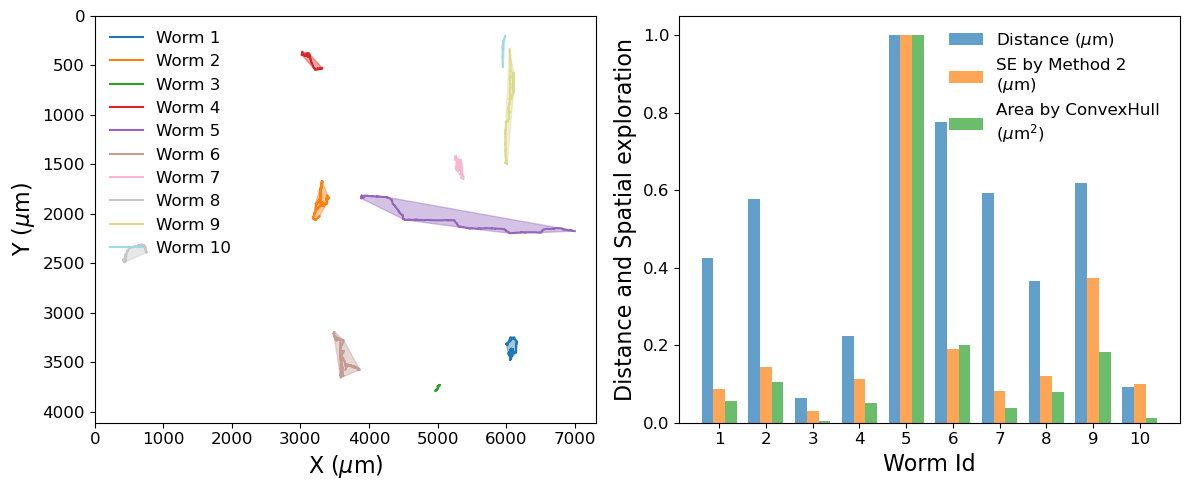

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull


worm_ids = sorted(coords_df["obj_id"].unique())

# Figure A : Trajectories + Convex Hull
fig, ax = plt.subplots(1,2, figsize=(12,5))

colors = plt.cm.tab20(np.linspace(0,1,len(worm_ids)))

for i, worm_id in enumerate(worm_ids):

    df_w = coords_df[coords_df["obj_id"] == worm_id]

    x = df_w["x (µm)"].values
    y = df_w["y (µm)"].values

    points = np.column_stack((x,y))

    ax[0].plot(x, y, '-', color=colors[i], label=f"Worm {worm_id}")

    # convex hull
    if len(points) > 3:
        hull = ConvexHull(points)

        hull_pts = points[hull.vertices]

        ax[0].fill(hull_pts[:,0],hull_pts[:,1],color=colors[i],alpha=0.4)



ax[0].set_xlabel("X ($\\mu$m)", fontsize=16)
ax[0].set_ylabel("Y ($\\mu$m)", fontsize=16)
ax[0].set_xlim(0, width*scale)
ax[0].set_ylim(0, height*scale)
ax[0].invert_yaxis()
ax[0].legend(loc="upper left", fontsize=12, frameon=False)
ax[0].tick_params(axis='both', labelsize=12)

worm_ids = summary["worm_id"].values
distance = summary["Distance (µm)"].values
area_method2 = summary["Method2_extent (µm)"].values
area_hull = summary["ConvexHull_area (µm^2)"].values

distance = distance/np.max(distance)
area_method2 = area_method2/np.max(area_method2)
area_hull = area_hull/np.max(area_hull)

x = np.arange(1, len(worm_ids)+1)
bar_width = 0.25

ax[1].bar(x - bar_width, distance, bar_width, label="Distance ($\\mu$m)", color="tab:blue", alpha=0.7)
ax[1].bar(x, area_method2, bar_width, label="SE by Method 2 \n($\\mu$m)", color="tab:orange", alpha=0.7)
ax[1].bar(x + bar_width, area_hull, bar_width, label="Area by ConvexHull \n($\\mu$m$^{2}$)", color="tab:green", alpha=0.7)
ax[1].set_xticks(np.arange(1, len(worm_ids)+1, 1))
ax[1].legend(loc="upper right", fontsize=12, frameon=False)
ax[1].tick_params(axis='both', labelsize=12)
ax[1].set_xlabel("Worm Id", fontsize=16)
ax[1].set_ylabel("Distance and Spatial exploration", fontsize=16)
# ax[1].set_ylim(0,1.3)

plt.tight_layout()
plt.show()